### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Identify Categorical & Numerical Columns

In [2]:
def identify_columns(data):
    categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
    numerical_columns = data.select_dtypes(include=['number']).columns.tolist()
    return categorical_columns, numerical_columns

### Cleaning & Processing of Data

In [3]:
# Function to clean and preprocess data
def clean_and_preprocess(data):
    # Display missing values before imputation
    print("Missing values before imputation:")
    print(data.isnull().sum())

    # Visualize missing values with a heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
    plt.title('Heatmap of Missing Values')
    plt.show()

# Calculate and print the number of rows with more than half of the columns missing
    threshold = len(data.columns) / 2
    rows_with_many_missing = data.isnull().sum(axis=1) >= threshold
    num_rows_with_many_missing = rows_with_many_missing.sum()
    print(f"Number of rows with more than or equal to half of the columns missing: {num_rows_with_many_missing}")

    # Remove rows with more than half of their columns empty
    data = data.dropna(thresh=threshold)
    print(f"Data shape after removing rows with more than half columns empty: {data.shape}")

    # Impute missing values
    def impute_missing_values(df):
        for column in df.select_dtypes(include=['object']).columns:  # Categorical columns
            mode_value = df[column].mode().iloc[0]
            df[column].fillna(mode_value, inplace=True)

        for column in df.select_dtypes(include=['number']).columns:  # Numerical columns
            median_value = df[column].median()
            df[column].fillna(median_value, inplace=True)

        return df

    data = impute_missing_values(data)

    # Check missing values after imputation
    print("Missing values after imputation:")
    print(data.isnull().sum())

    # Remove duplicates
    data.drop_duplicates(inplace=True)

    # Remove outliers using IQR method
    def remove_outliers(df, column):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        return df

    for col in data.select_dtypes(include=['number']).columns:
        data = remove_outliers(data, col)

    # Round numerical columns to 2 decimal places
    data = data.round(2)

    return data

### Loading the Dataset and the Sheets

In [4]:
# Load all sheets from the Excel file
file_path = '/content/Raw_Operational Efficiency and Financial Forecasting_3-8-2024_Parth Babbar.xlsx'
sheets = pd.read_excel(file_path, sheet_name=None)  # sheet_name=None loads all sheets

# Dictionary to hold cleaned data for each sheet
cleaned_sheets = {}

for sheet_name, data in sheets.items():
    print(f"Processing sheet: {sheet_name}")

    # Identify categorical and numerical columns
    categorical_columns, numerical_columns = identify_columns(data)

    print(f"Categorical columns in {sheet_name}: {categorical_columns}")
    print(f"Numerical columns in {sheet_name}: {numerical_columns}")
    print("\n")

Processing sheet: Cash_Flow_Data
Categorical columns in Cash_Flow_Data: ['Branch_ID', 'Region', 'Major_Events']
Numerical columns in Cash_Flow_Data: ['Year', 'Total_Cash_Inflow', 'Total_Cash_Outflow', 'Net_Cash_Flow', 'Cash_Balance', 'Forecasted_Cash_Inflow', 'Forecasted_Cash_Outflow', 'Forecasted_Net_Cash_Flow', 'Forecast_Accuracy_%']


Processing sheet: ATM_Maintenance_Performance
Categorical columns in ATM_Maintenance_Performance: ['Branch_ID', 'Region', 'ATM_ID', 'Location', 'Maintenance_Type', 'Model_Manufacturer', 'Error_Codes']
Numerical columns in ATM_Maintenance_Performance: ['Year', 'Transaction_Volume', 'Transaction_Value', 'Cash_Dispensed', 'Cash_Loaded', 'Downtime_hours', 'Maintenance_Year', 'Maintenance_Cost', 'Age_of_ATM', 'Customer_Complaints', 'Average_Queue_Time']


Processing sheet: Financial_Product_Performance
Categorical columns in Financial_Product_Performance: ['Branch_ID', 'Region', 'Product_ID', 'Product_Name', 'Product_Category', 'Acquisition_Channel']
Numeri

In [5]:
sheet_name

'Operational_Metrics'

### Cleaning Each Sheet

#### Cash Flow Data Sheet

Missing values before imputation:
Year                        207
Branch_ID                   212
Region                      205
Total_Cash_Inflow           210
Total_Cash_Outflow          214
Net_Cash_Flow               209
Cash_Balance                211
Forecasted_Cash_Inflow      209
Forecasted_Cash_Outflow     212
Forecasted_Net_Cash_Flow    208
Forecast_Accuracy_%         211
Major_Events                829
dtype: int64


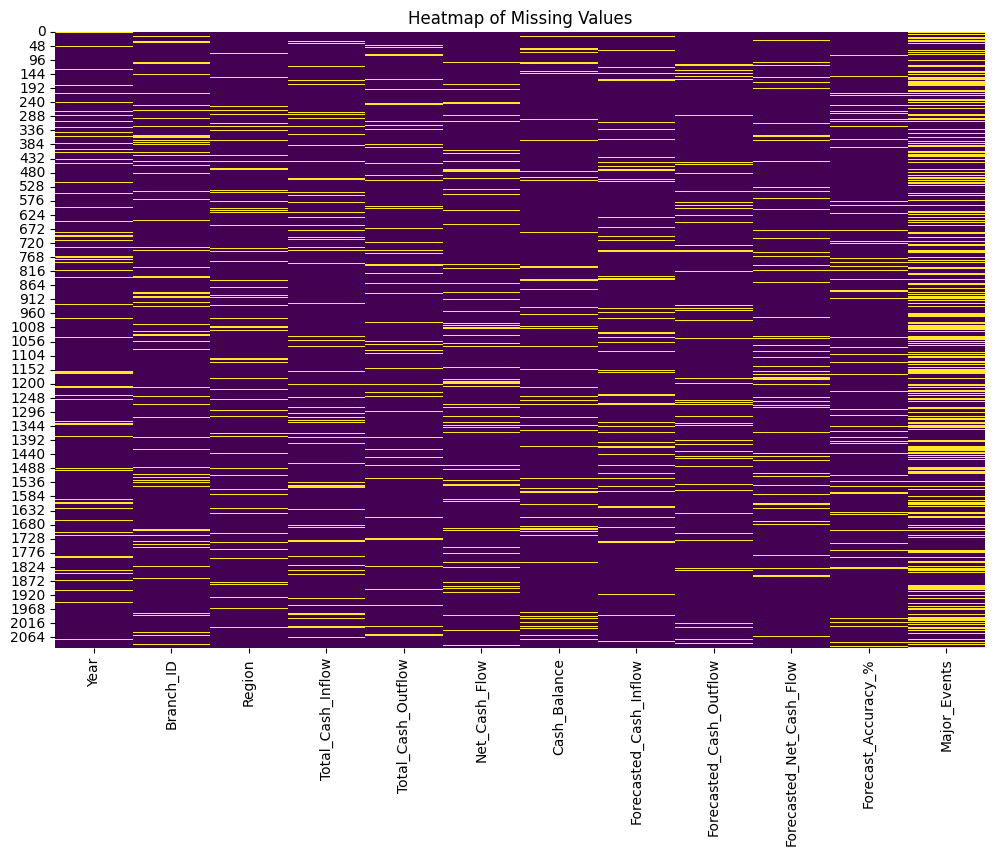

Number of rows with more than or equal to half of the columns missing: 2
Data shape after removing rows with more than half columns empty: (2100, 12)
Missing values after imputation:
Year                        0
Branch_ID                   0
Region                      0
Total_Cash_Inflow           0
Total_Cash_Outflow          0
Net_Cash_Flow               0
Cash_Balance                0
Forecasted_Cash_Inflow      0
Forecasted_Cash_Outflow     0
Forecasted_Net_Cash_Flow    0
Forecast_Accuracy_%         0
Major_Events                0
dtype: int64


In [6]:
# Process the 'Cash Flow Data' sheet
sheet_name = 'Cash_Flow_Data'
cleaned_sheets[sheet_name] = clean_and_preprocess(sheets[sheet_name])

#### ATM Maintenance Data Sheet

Missing values before imputation:
Year                   213
Branch_ID              204
Region                 204
ATM_ID                 210
Location               214
Transaction_Volume     208
Transaction_Value      208
Cash_Dispensed         211
Cash_Loaded            209
Downtime_hours         207
Maintenance_Year       215
Maintenance_Type       213
Maintenance_Cost       212
Age_of_ATM             208
Model_Manufacturer     207
Error_Codes            685
Customer_Complaints    212
Average_Queue_Time     217
dtype: int64


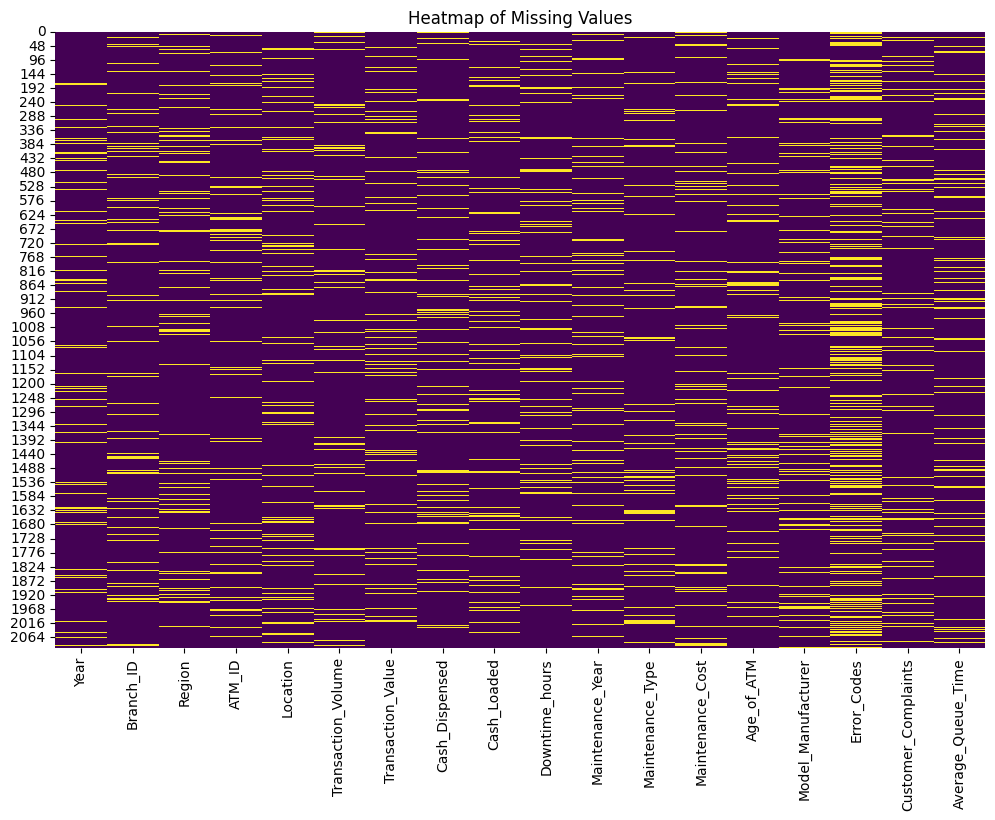

Number of rows with more than or equal to half of the columns missing: 0
Data shape after removing rows with more than half columns empty: (2100, 18)
Missing values after imputation:
Year                   0
Branch_ID              0
Region                 0
ATM_ID                 0
Location               0
Transaction_Volume     0
Transaction_Value      0
Cash_Dispensed         0
Cash_Loaded            0
Downtime_hours         0
Maintenance_Year       0
Maintenance_Type       0
Maintenance_Cost       0
Age_of_ATM             0
Model_Manufacturer     0
Error_Codes            0
Customer_Complaints    0
Average_Queue_Time     0
dtype: int64


In [7]:
# Process the 'ATM Maintenance Data' sheet
sheet_name = 'ATM_Maintenance_Performance'
cleaned_sheets[sheet_name] = clean_and_preprocess(sheets[sheet_name])

#### Financial Product Data Sheet

Missing values before imputation:
Year                           213
Branch_ID                      206
Region                         213
Product_ID                     210
Product_Name                   204
Product_Category               206
Number_of_New_Accounts         213
Total_Account_Balance          212
Average_Account_Balance        215
Interest_Rate                  213
Fee_Income                     208
Churn_Rate                     208
Customer_Satisfaction_Score    209
Cross_Selling_Rate             211
Acquisition_Channel            211
Marketing_Spend                211
Profitability_Margin           214
Risk_Score                     212
dtype: int64


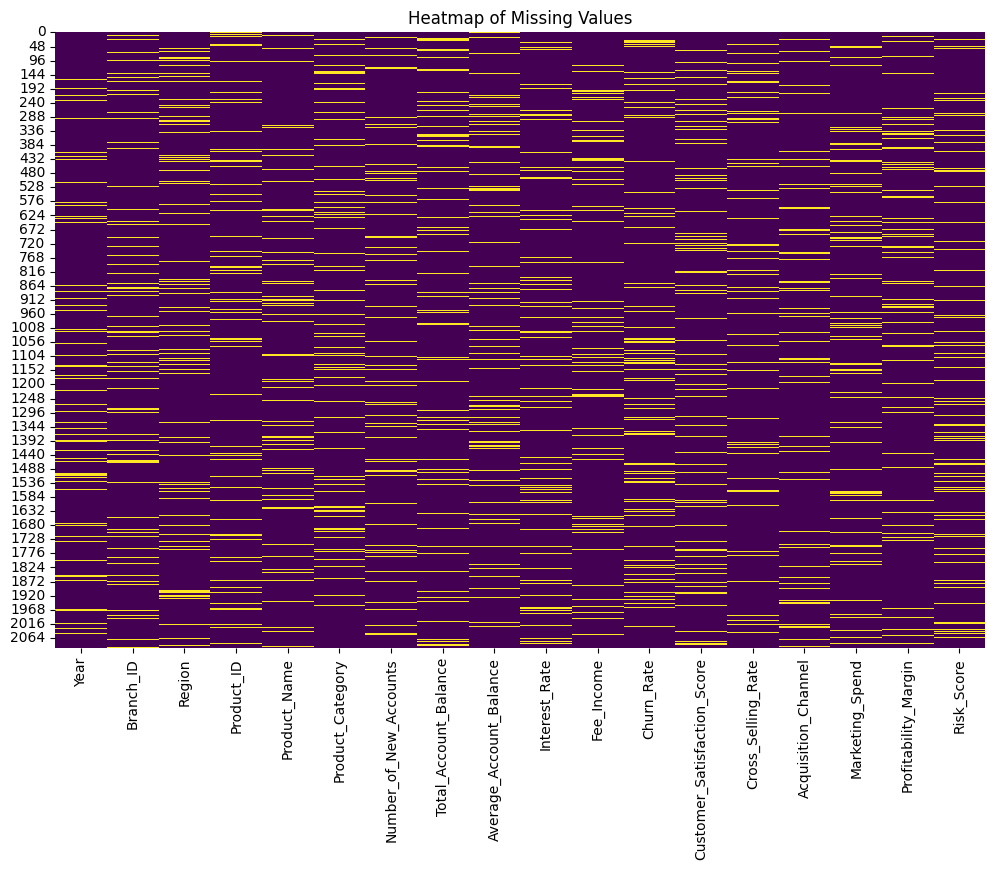

Number of rows with more than or equal to half of the columns missing: 0
Data shape after removing rows with more than half columns empty: (2100, 18)
Missing values after imputation:
Year                           0
Branch_ID                      0
Region                         0
Product_ID                     0
Product_Name                   0
Product_Category               0
Number_of_New_Accounts         0
Total_Account_Balance          0
Average_Account_Balance        0
Interest_Rate                  0
Fee_Income                     0
Churn_Rate                     0
Customer_Satisfaction_Score    0
Cross_Selling_Rate             0
Acquisition_Channel            0
Marketing_Spend                0
Profitability_Margin           0
Risk_Score                     0
dtype: int64


In [8]:
# Process the 'Financial Product Data' sheet
sheet_name = 'Financial_Product_Performance'
cleaned_sheets[sheet_name] = clean_and_preprocess(sheets[sheet_name])

#### Operational Metrics Data Sheet

Missing values before imputation:
Year                           204
Branch_ID                      210
Region                         214
Number_of_Employees            210
Employee_Productivity          211
Customer_Wait_Time             205
Transaction_Processing_Time    208
Error_Rate                     204
System_Uptime_%                214
Digital_Channel_Usage_%        208
Cost_per_Transaction           210
Customer_Satisfaction_Score    208
Employee_Satisfaction_Score    206
Training_Hours                 212
Compliance_Score               208
Energy_Consumption             208
dtype: int64


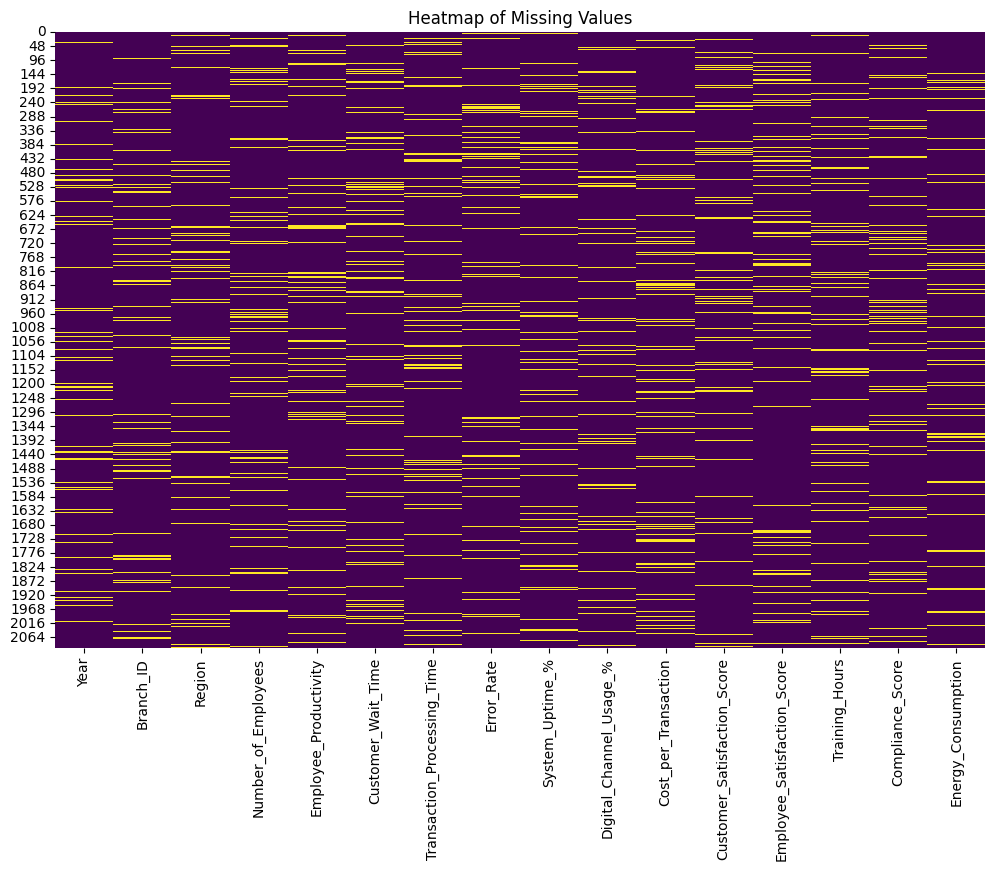

Number of rows with more than or equal to half of the columns missing: 0
Data shape after removing rows with more than half columns empty: (2100, 16)
Missing values after imputation:
Year                           0
Branch_ID                      0
Region                         0
Number_of_Employees            0
Employee_Productivity          0
Customer_Wait_Time             0
Transaction_Processing_Time    0
Error_Rate                     0
System_Uptime_%                0
Digital_Channel_Usage_%        0
Cost_per_Transaction           0
Customer_Satisfaction_Score    0
Employee_Satisfaction_Score    0
Training_Hours                 0
Compliance_Score               0
Energy_Consumption             0
dtype: int64


In [9]:
# Process the 'Operational Metrics Data' sheet
sheet_name = 'Operational_Metrics'
cleaned_sheets[sheet_name] = clean_and_preprocess(sheets[sheet_name])

### Summary & Frequency Table

In [10]:
# Generate summary statistics and frequency tables for each sheet
for sheet_name, data in cleaned_sheets.items():
    print(f"Summary statistics for numerical columns in {sheet_name}:\n")
    print(data.describe())  # Summary statistics for numerical columns

    print(f"Frequency table for categorical columns in {sheet_name}:\n")
    categorical_columns = data.select_dtypes(include=['object']).columns
    frequency_table = data[categorical_columns].apply(pd.Series.value_counts)
    print(frequency_table)
    print("\n")

Summary statistics for numerical columns in Cash_Flow_Data:

              Year  Total_Cash_Inflow  Total_Cash_Outflow  Net_Cash_Flow  \
count  1665.000000        1665.000000         1665.000000    1665.000000   
mean   2013.911712          99.225694           90.614486      10.314216   
std       5.177964          17.816327           22.611882       8.801622   
min    2005.000000          52.900000           31.410000     -12.690000   
25%    2010.000000          87.950000           76.040000       4.630000   
50%    2014.000000          99.680000           91.120000      10.280000   
75%    2018.000000         110.310000          104.290000      15.990000   
max    2023.000000         145.750000          150.200000      33.680000   

       Cash_Balance  Forecasted_Cash_Inflow  Forecasted_Cash_Outflow  \
count   1665.000000             1665.000000              1665.000000   
mean     497.059117              104.674661                95.525772   
std       89.051086               16.5

### Saving the Cleaned Sheets in a Single Dataset

In [11]:
# Save all cleaned sheets into one Excel file
cleaned_file_path = '/content/cleaned_banking_dataset.xlsx'
with pd.ExcelWriter(cleaned_file_path) as writer:
    for sheet_name, data in cleaned_sheets.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Cleaned data saved to {cleaned_file_path}")

Cleaned data saved to /content/cleaned_banking_dataset.xlsx
